<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/06test_train_simpleImputor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('data.csv')
imputer = SimpleImputer(strategy='median')
df[['Age', 'Salary']] = imputer.fit_transform(df[['Age', 'Salary']])
X = df.drop('Target', axis=1)
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Data Leakage Issue
The SimpleImputer computes the median using the entire dataset before the train-test split occurs.

Why It Is Wrong

Unseen Data Leakage: The test set must mimic completely unseen data.

Biased Statistics: Including test rows in the median calculation leaks information.

Overoptimistic Evaluation: It leads to unrealistically high performance metrics during testing.

Production Failure: The model will perform poorly on real, future data.


Correct code

In [2]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# 1. Load data
df = pd.read_csv("data.csv")
X = df.drop("Target", axis=1)
y = df["Target"]

# 2. Split first to prevent leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Initialize the imputer
imputer = SimpleImputer(strategy="median")

# 4. Fit and transform training data ONLY
X_train[["Age", "Salary"]] = imputer.fit_transform(X_train[["Age", "Salary"]])

# 5. Transform test data using training statistics
X_test[["Age", "Salary"]] = imputer.transform(X_test[["Age", "Salary"]])


Total missing values in each column

Percentage of missing values per column

Which columns have more than 50% missing values?


In [3]:
df.isnull().sum()

,0
Age,180
Income,150
Salary,0
Rating,80
Annual_Income,120
Customer_Support_Calls,80
House_Price,100
Square_Feet,0
Temperature,50
City,50


In [4]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

Age                       18.0
Income                    15.0
Salary                     0.0
Rating                     8.0
Annual_Income             12.0
Customer_Support_Calls     8.0
House_Price               10.0
Square_Feet                0.0
Temperature                5.0
City                       5.0
Product_Type               0.0
Location                   0.0
Diagnosis                 22.0
Cabin                     68.0
Embarked                   0.2
Gender                     0.0
Target                     0.0
Price_Target               0.0
dtype: float64


In [5]:
columns_above_50_percent_missing = missing_percentage[missing_percentage > 50]
# columns_above_50_percent_missing = missing_percentage[missing_percentage > 50].index.tolist()
print(columns_above_50_percent_missing)

Cabin    68.0
dtype: float64


Question: Look at the Temperature column in data.csv. It contains:
Numeric values like 22.5, 18.6

String 'Unknown'

NaN values

Write code to handle this column properly before imputation.


In [6]:
df

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Target,Price_Target
0,40.0,9165.0,55361,2.9,NaN,NaN,495310.0,2091,15.1,Dhaka,Unknown,A,NaN,NaN,S,Male,0,280.32
1,33.0,5522.0,48717,NaN,52868.0,1.0,368695.0,1504,28.3,Chittagong,C,C,Type3,NaN,S,Female,1,314.83
2,42.0,50589.0,64787,3.1,79526.0,2.0,453606.0,2052,22.0,Sylhet,A,C,Type1,NaN,C,Female,0,252.43
3,53.0,61289.0,80106,3.6,107581.0,1.0,359753.0,2075,22.7,Rajshahi,C,B,Type2,NaN,S,Female,0,239.21
4,32.0,1604.0,31872,4.0,89654.0,1.0,228869.0,1248,NaN,Rajshahi,A,C,Type2,NaN,S,Female,0,179.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31.0,16472.0,50253,3.2,82289.0,4.0,NaN,1832,17.0,Dhaka,A,C,Type1,NaN,C,Female,0,309.92
996,56.0,11596.0,41951,2.7,32733.0,2.0,NaN,1127,17.0,Sylhet,A,C,Type1,Cabin_D,S,Male,0,222.41
997,42.0,NaN,44369,2.6,50537.0,2.0,346644.0,1654,24.7,Rajshahi,C,B,Type2,NaN,S,Female,0,221.89
998,NaN,276.0,52691,3.9,143880.0,4.0,307904.0,1908,Unknown,Rajshahi,B,B,NaN,NaN,Q,Female,0,293.69


In [7]:
import numpy as np

In [8]:
df.loc[df['Temperature'] == 'Unknown', 'Temperature'] = np.nan

In [9]:
df

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Target,Price_Target
0,40.0,9165.0,55361,2.9,NaN,NaN,495310.0,2091,15.1,Dhaka,Unknown,A,NaN,NaN,S,Male,0,280.32
1,33.0,5522.0,48717,NaN,52868.0,1.0,368695.0,1504,28.3,Chittagong,C,C,Type3,NaN,S,Female,1,314.83
2,42.0,50589.0,64787,3.1,79526.0,2.0,453606.0,2052,22.0,Sylhet,A,C,Type1,NaN,C,Female,0,252.43
3,53.0,61289.0,80106,3.6,107581.0,1.0,359753.0,2075,22.7,Rajshahi,C,B,Type2,NaN,S,Female,0,239.21
4,32.0,1604.0,31872,4.0,89654.0,1.0,228869.0,1248,NaN,Rajshahi,A,C,Type2,NaN,S,Female,0,179.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31.0,16472.0,50253,3.2,82289.0,4.0,NaN,1832,17.0,Dhaka,A,C,Type1,NaN,C,Female,0,309.92
996,56.0,11596.0,41951,2.7,32733.0,2.0,NaN,1127,17.0,Sylhet,A,C,Type1,Cabin_D,S,Male,0,222.41
997,42.0,NaN,44369,2.6,50537.0,2.0,346644.0,1654,24.7,Rajshahi,C,B,Type2,NaN,S,Female,0,221.89
998,NaN,276.0,52691,3.9,143880.0,4.0,307904.0,1908,NaN,Rajshahi,B,B,NaN,NaN,Q,Female,0,293.69


Question: For the Diagnosis column in data.csv, implement imputation with:

Constant strategy using 'Missing' string

Add a missing indicator column


Write the complete code using SimpleImputer.


In [10]:
X = df.drop(['Target'], axis= 1)
X

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Price_Target
0,40.0,9165.0,55361,2.9,NaN,NaN,495310.0,2091,15.1,Dhaka,Unknown,A,NaN,NaN,S,Male,280.32
1,33.0,5522.0,48717,NaN,52868.0,1.0,368695.0,1504,28.3,Chittagong,C,C,Type3,NaN,S,Female,314.83
2,42.0,50589.0,64787,3.1,79526.0,2.0,453606.0,2052,22.0,Sylhet,A,C,Type1,NaN,C,Female,252.43
3,53.0,61289.0,80106,3.6,107581.0,1.0,359753.0,2075,22.7,Rajshahi,C,B,Type2,NaN,S,Female,239.21
4,32.0,1604.0,31872,4.0,89654.0,1.0,228869.0,1248,NaN,Rajshahi,A,C,Type2,NaN,S,Female,179.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31.0,16472.0,50253,3.2,82289.0,4.0,NaN,1832,17.0,Dhaka,A,C,Type1,NaN,C,Female,309.92
996,56.0,11596.0,41951,2.7,32733.0,2.0,NaN,1127,17.0,Sylhet,A,C,Type1,Cabin_D,S,Male,222.41
997,42.0,NaN,44369,2.6,50537.0,2.0,346644.0,1654,24.7,Rajshahi,C,B,Type2,NaN,S,Female,221.89
998,NaN,276.0,52691,3.9,143880.0,4.0,307904.0,1908,NaN,Rajshahi,B,B,NaN,NaN,Q,Female,293.69


In [11]:
y = df['Target']
y

,Target
0,0
1,1
2,0
3,0
4,0
...,...
995,0
996,0
997,0
998,0


In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
X_train.isnull().sum()

,0
Age,139
Income,126
Salary,0
Rating,66
Annual_Income,97
Customer_Support_Calls,62
House_Price,83
Square_Feet,0
Temperature,99
City,38


In [14]:
X_test.isnull().sum()

,0
Age,41
Income,24
Salary,0
Rating,14
Annual_Income,23
Customer_Support_Calls,18
House_Price,17
Square_Feet,0
Temperature,16
City,12


In [15]:
from sklearn.impute import SimpleImputer

In [16]:
diagnosis_imputor = SimpleImputer(missing_values=np.nan, strategy = 'constant', fill_value = 'Missing', add_indicator = True)
diagnosis_imputor.fit(X_train[['Diagnosis']])

X_train[['Diagnosis', 'Diagnosisi missing indicator']] = diagnosis_imputor.transform(X_train[['Diagnosis']])

X_test[['Diagnosis', 'Diagnosisi missing indicator']] = diagnosis_imputor.transform(X_test[['Diagnosis']])

In [17]:
X_train

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Price_Target,Diagnosisi missing indicator
29,NaN,20541.0,46632,4.2,30172.0,1.0,111387.0,1866,32.5,Chittagong,B,B,Type1,NaN,S,Male,231.94,False
535,35.0,46050.0,71684,2.8,72318.0,2.0,289801.0,2067,28.2,Dhaka,B,B,Missing,NaN,Q,Female,228.30,True
695,31.0,8652.0,85790,1.4,NaN,4.0,227513.0,1812,24.2,NaN,C,C,Missing,NaN,C,Male,266.84,True
557,29.0,93707.0,52109,4.5,100627.0,1.0,191999.0,1510,24.5,Dhaka,A,B,Missing,NaN,S,Female,221.75,True
836,53.0,41021.0,61257,1.9,52816.0,1.0,106457.0,1438,21.8,Sylhet,B,C,Missing,NaN,S,Female,261.28,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,57.0,1868.0,53454,4.1,55001.0,3.0,NaN,1115,27.2,Chittagong,A,A,Type1,NaN,S,Female,161.48,False
270,52.0,55063.0,52856,3.1,111554.0,2.0,162436.0,2028,23.6,Sylhet,B,A,Missing,NaN,C,Female,303.58,True
860,37.0,7655.0,54442,3.7,40181.0,5.0,231088.0,1142,21.6,Chittagong,Unknown,A,Type1,NaN,S,Female,327.19,False
435,35.0,48894.0,50286,4.1,96119.0,3.0,NaN,1722,24.5,Chittagong,A,A,Type2,NaN,S,Male,311.50,False


In [18]:
X_train.isnull().sum()

,0
Age,139
Income,126
Salary,0
Rating,66
Annual_Income,97
Customer_Support_Calls,62
House_Price,83
Square_Feet,0
Temperature,99
City,38


Question: Using the Age column from data.csv:

Calculate mean and median from training data only

Create two new columns: Age_mean_imputed and Age_median_imputed

Plot KDE for both to compare distributions

Which one would you choose and why?

In [19]:
age_mean = X_train['Age'].mean()

X_train['Age_mean_imputor'] = X_train['Age'].fillna(age_mean)
X_test['Age_mean_imputor'] = X_test['Age'].fillna(age_mean)

In [20]:
age_median = X_train['Age'].median()


X_train['age_median_imputor'] = X_train['Age'].fillna(age_median)

X_test['age_median_imputor'] = X_test['Age'].fillna(age_median)

X_train

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Price_Target,Diagnosisi missing indicator,Age_mean_imputor,age_median_imputor
29,NaN,20541.0,46632,4.2,30172.0,1.0,111387.0,1866,32.5,Chittagong,B,B,Type1,NaN,S,Male,231.94,False,34.633888,34.0
535,35.0,46050.0,71684,2.8,72318.0,2.0,289801.0,2067,28.2,Dhaka,B,B,Missing,NaN,Q,Female,228.30,True,35.000000,35.0
695,31.0,8652.0,85790,1.4,NaN,4.0,227513.0,1812,24.2,NaN,C,C,Missing,NaN,C,Male,266.84,True,31.000000,31.0
557,29.0,93707.0,52109,4.5,100627.0,1.0,191999.0,1510,24.5,Dhaka,A,B,Missing,NaN,S,Female,221.75,True,29.000000,29.0
836,53.0,41021.0,61257,1.9,52816.0,1.0,106457.0,1438,21.8,Sylhet,B,C,Missing,NaN,S,Female,261.28,True,53.000000,53.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,57.0,1868.0,53454,4.1,55001.0,3.0,NaN,1115,27.2,Chittagong,A,A,Type1,NaN,S,Female,161.48,False,57.000000,57.0
270,52.0,55063.0,52856,3.1,111554.0,2.0,162436.0,2028,23.6,Sylhet,B,A,Missing,NaN,C,Female,303.58,True,52.000000,52.0
860,37.0,7655.0,54442,3.7,40181.0,5.0,231088.0,1142,21.6,Chittagong,Unknown,A,Type1,NaN,S,Female,327.19,False,37.000000,37.0
435,35.0,48894.0,50286,4.1,96119.0,3.0,NaN,1722,24.5,Chittagong,A,A,Type2,NaN,S,Male,311.50,False,35.000000,35.0


In [21]:
import seaborn as sns

<Axes: xlabel='Age_mean_imputor', ylabel='Density'>

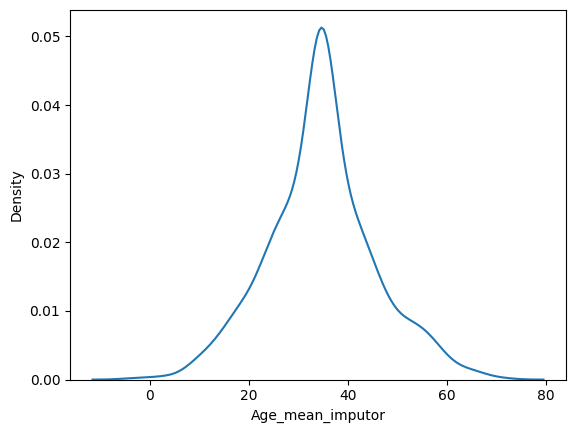

In [22]:
sns.kdeplot(data=X_train , x='Age_mean_imputor')

<Axes: xlabel='age_median_imputor', ylabel='Density'>

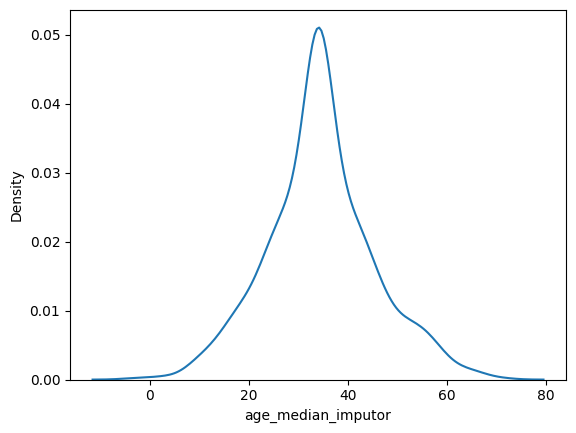

In [23]:
sns.kdeplot(data=X_train , x='age_median_imputor')

In [24]:
age_imputer = SimpleImputer(missing_values=np.nan , strategy='mean')

age_imputer.fit(X_train[['Age']])

X_train['age_mean_imputor_with_simpleImputor'] = age_imputer.transform(X_train[['Age']])
# X_train['age_mean_imputor_with_simpleImputor'] = age_imputer.transform(X_train[['Age']]).ravel()

X_train

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,...,Location,Diagnosis,Cabin,Embarked,Gender,Price_Target,Diagnosisi missing indicator,Age_mean_imputor,age_median_imputor,age_mean_imputor_with_simpleImputor
29,NaN,20541.0,46632,4.2,30172.0,1.0,111387.0,1866,32.5,Chittagong,...,B,Type1,NaN,S,Male,231.94,False,34.633888,34.0,34.633888
535,35.0,46050.0,71684,2.8,72318.0,2.0,289801.0,2067,28.2,Dhaka,...,B,Missing,NaN,Q,Female,228.30,True,35.000000,35.0,35.000000
695,31.0,8652.0,85790,1.4,NaN,4.0,227513.0,1812,24.2,NaN,...,C,Missing,NaN,C,Male,266.84,True,31.000000,31.0,31.000000
557,29.0,93707.0,52109,4.5,100627.0,1.0,191999.0,1510,24.5,Dhaka,...,B,Missing,NaN,S,Female,221.75,True,29.000000,29.0,29.000000
836,53.0,41021.0,61257,1.9,52816.0,1.0,106457.0,1438,21.8,Sylhet,...,C,Missing,NaN,S,Female,261.28,True,53.000000,53.0,53.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,57.0,1868.0,53454,4.1,55001.0,3.0,NaN,1115,27.2,Chittagong,...,A,Type1,NaN,S,Female,161.48,False,57.000000,57.0,57.000000
270,52.0,55063.0,52856,3.1,111554.0,2.0,162436.0,2028,23.6,Sylhet,...,A,Missing,NaN,C,Female,303.58,True,52.000000,52.0,52.000000
860,37.0,7655.0,54442,3.7,40181.0,5.0,231088.0,1142,21.6,Chittagong,...,A,Type1,NaN,S,Female,327.19,False,37.000000,37.0,37.000000
435,35.0,48894.0,50286,4.1,96119.0,3.0,NaN,1722,24.5,Chittagong,...,A,Type2,NaN,S,Male,311.50,False,35.000000,35.0,35.000000


1. Income

Best Strategy: Median Imputation
Justification: The data is highly right-skewed. Extreme high-income outliers will pull the mean upward, making it unrepresentative of the typical value. The median is robust against outliers and accurately captures the central tendency of skewed distributions.

2. Rating

Best Strategy: Mean Imputation
Justification: The column follows a symmetric, normal distribution with a low missing rate (8%). For perfectly bell-shaped data without heavy outliers, the mean is the most statistically sound and efficient representation of the center.

3. City

Best Strategy: Mode (Most Frequent) Imputation
Justification: This is a categorical column with low missingness (5%). Since one single city heavily dominates the data (40% of all entries across 50 categories), imputing the mode is a safe choice that aligns with the natural probability distribution of the dataset.

4. Diagnosis

Best Strategy: Create a "Missing" Placeholder Category
Justification: The missing rate is high (22%), and the existing target categories are perfectly balanced (~33% each). Imputing the mode would completely destroy this balance and introduce severe bias. Treating the missing values as a distinct new category (e.g., 'Unknown') preserves the balance and allows the model to learn if the data is missing for a specific structural reason.

5. Cabin

Best Strategy: Drop the Column (or encode as a Binary Indicator: Has_Cabin vs No_Cabin)
Justification: With 68% of the data missing and no dominant category, any standard statistical imputation will fill the column with massive artificial noise. Dropping the column is the cleanest approach. Alternatively, you can convert the column into a binary flag (1 if a cabin is listed, 0 if missing), as the absence of a cabin often carries meaningful predictive information (e.g., as seen in the Titanic dataset).


In [25]:
temperature_imputor = SimpleImputer(missing_values = np.nan, strategy = 'mean')

temperature_imputor.fit(X_train[['Temperature']])

X_train['Temperature'] = temperature_imputor.transform(X_train[['Temperature']])

In [26]:
X_train

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,...,Location,Diagnosis,Cabin,Embarked,Gender,Price_Target,Diagnosisi missing indicator,Age_mean_imputor,age_median_imputor,age_mean_imputor_with_simpleImputor
29,NaN,20541.0,46632,4.2,30172.0,1.0,111387.0,1866,32.5,Chittagong,...,B,Type1,NaN,S,Male,231.94,False,34.633888,34.0,34.633888
535,35.0,46050.0,71684,2.8,72318.0,2.0,289801.0,2067,28.2,Dhaka,...,B,Missing,NaN,Q,Female,228.30,True,35.000000,35.0,35.000000
695,31.0,8652.0,85790,1.4,NaN,4.0,227513.0,1812,24.2,NaN,...,C,Missing,NaN,C,Male,266.84,True,31.000000,31.0,31.000000
557,29.0,93707.0,52109,4.5,100627.0,1.0,191999.0,1510,24.5,Dhaka,...,B,Missing,NaN,S,Female,221.75,True,29.000000,29.0,29.000000
836,53.0,41021.0,61257,1.9,52816.0,1.0,106457.0,1438,21.8,Sylhet,...,C,Missing,NaN,S,Female,261.28,True,53.000000,53.0,53.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,57.0,1868.0,53454,4.1,55001.0,3.0,NaN,1115,27.2,Chittagong,...,A,Type1,NaN,S,Female,161.48,False,57.000000,57.0,57.000000
270,52.0,55063.0,52856,3.1,111554.0,2.0,162436.0,2028,23.6,Sylhet,...,A,Missing,NaN,C,Female,303.58,True,52.000000,52.0,52.000000
860,37.0,7655.0,54442,3.7,40181.0,5.0,231088.0,1142,21.6,Chittagong,...,A,Type1,NaN,S,Female,327.19,False,37.000000,37.0,37.000000
435,35.0,48894.0,50286,4.1,96119.0,3.0,NaN,1722,24.5,Chittagong,...,A,Type2,NaN,S,Male,311.50,False,35.000000,35.0,35.000000


In [27]:
X_test['Temperature'] = temperature_imputor.transform(X_test[['Temperature']])

In [28]:
X_test

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Price_Target,Diagnosisi missing indicator,Age_mean_imputor,age_median_imputor
521,41.0,73315.0,57252,3.8,93298.0,4.0,157109.0,2215,20.8,Dhaka,Unknown,A,Type1,NaN,S,Male,223.00,False,41.000000,41.0
737,46.0,178787.0,55297,4.8,126876.0,0.0,419358.0,1092,28.7,Dhaka,C,A,Type2,NaN,S,Female,233.71,False,46.000000,46.0
740,NaN,6057.0,66301,3.3,40303.0,1.0,314431.0,2628,21.9,Dhaka,Unknown,C,Type1,NaN,C,Female,256.23,False,34.633888,34.0
660,28.0,51440.0,64413,3.4,NaN,2.0,270048.0,2261,25.5,Chittagong,Unknown,B,Type2,NaN,C,Male,236.42,False,28.000000,28.0
411,21.0,12169.0,60287,2.0,35858.0,0.0,NaN,1717,22.0,Chittagong,A,C,Type3,NaN,S,Male,322.29,False,21.000000,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,36.0,28947.0,62845,2.3,15326.0,2.0,267695.0,2301,29.7,Dhaka,B,B,Type2,NaN,S,Male,217.31,False,36.000000,36.0
332,35.0,5083.0,21564,4.3,63630.0,3.0,428279.0,2197,21.9,Khulna,C,A,Type1,Cabin_C,S,Male,298.54,False,35.000000,35.0
208,41.0,23917.0,65271,2.7,NaN,0.0,387398.0,2418,21.3,Dhaka,A,A,Type1,Cabin_A,S,Female,244.72,False,41.000000,41.0
613,21.0,8060.0,61040,3.2,98569.0,NaN,98509.0,2784,24.4,Chittagong,B,B,Type1,NaN,S,Male,192.67,False,21.000000,21.0


In [29]:
X_train.isnull().sum()

,0
Age,139
Income,126
Salary,0
Rating,66
Annual_Income,97
Customer_Support_Calls,62
House_Price,83
Square_Feet,0
Temperature,0
City,38
